# Технологии Машинного Обучения РК №1 
# Группа: ИУ5-62Б
# Студент: Кудабаева Э.
# Преподаватель: Гапанюк Ю.Е.
# Вариант №12
# Задача №2, Датасет № 4

## https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

# Задача №2.
## Для заданного набора данных проведите обработку пропусков в данных для одного категориального и одного количественного признака. 
## Какие способы обработки пропусков в данных для категориальных и количественных признаков Вы использовали? 
## Какие признаки Вы будете использовать для дальнейшего построения моделей машинного обучения и почему?

# 1. Импорт данных и первичный анализ датасета

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

sns.set_style('whitegrid')

In [23]:
# Вариант 12 набор данных №4 (Heart Disease Dataset)
df = pd.read_csv('heart.csv')

print("Размер:", df.shape)
df.head()

Размер: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [25]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# Выводы:
# Датасет содержит 1025 строк и 14 столбцов
# Пропусков нет, все типы данных числовые
# Целевая переменная: `target` (1 — есть болезнь сердца, 0 — нет)


# 2. Создаём пропуски

In [26]:
df_miss = df.copy()
n = len(df_miss)

quant_col = 'thalach'
idx_quant = np.random.choice(df_miss.index, size=int(n * 0.1), replace=False)
df_miss.loc[idx_quant, quant_col] = np.nan

cat_col = 'cp'
idx_cat = np.random.choice(df_miss.index, size=int(n * 0.1), replace=False)
df_miss.loc[idx_cat, cat_col] = np.nan

print("Количество пропусков по столбцам:")
print(df_miss.isna().sum())
print(f"\nДоля пропусков в {quant_col}: {df_miss[quant_col].isna().mean():.1%}")
print(f"Доля пропусков в {cat_col}: {df_miss[cat_col].isna().mean():.1%}")

Количество пропусков по столбцам:
age           0
sex           0
cp          102
trestbps      0
chol          0
fbs           0
restecg       0
thalach     102
exang         0
oldpeak       0
slope         0
ca            0
thal          0
target        0
dtype: int64

Доля пропусков в thalach: 10.0%
Доля пропусков в cp: 10.0%


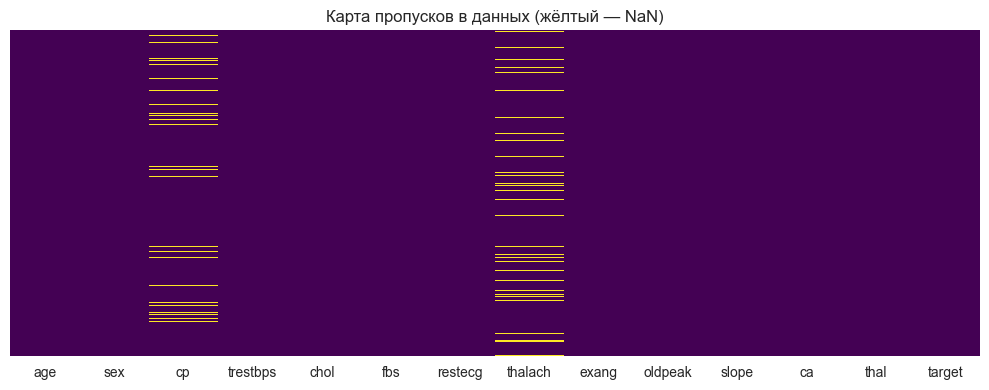

In [27]:
plt.figure(figsize=(10, 4))
sns.heatmap(df_miss.isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Карта пропусков в данных (жёлтый — NaN)')
plt.tight_layout()
plt.show()

# 3. Обработка пропусков - Кол-во признак

In [28]:
col_num = 'thalach'

# удаление
df_drop = df_miss.dropna(subset=[col_num]).copy()

# заполнение средним
imp_mean = SimpleImputer(strategy='mean')
df_mean = df_miss.copy()
df_mean[col_num] = imp_mean.fit_transform(df_mean[[col_num]])

# заполнение медианой
imp_median = SimpleImputer(strategy='median')
df_median = df_miss.copy()
df_median[col_num] = imp_median.fit_transform(df_median[[col_num]])

compare = pd.DataFrame({
    'Исходные': df[col_num].describe(),
    'С пропусками': df_miss[col_num].describe(),
    'Удаление строк': df_drop[col_num].describe(),
    'Заполнение средним': df_mean[col_num].describe(),
    'Заполнение медианой': df_median[col_num].describe(),
})
compare.round(1)

,Исходные,С пропусками,Удаление строк,Заполнение средним,Заполнение медианой
count,1025.0,923.0,923.0,1025.0,1025.0
mean,149.1,149.2,149.2,149.2,149.5
std,23.0,23.3,23.3,22.1,22.1
min,71.0,71.0,71.0,71.0,71.0
25%,132.0,132.0,132.0,138.0,138.0
50%,152.0,152.0,152.0,150.0,152.0
75%,166.0,166.5,166.5,164.0,164.0
max,202.0,202.0,202.0,202.0,202.0


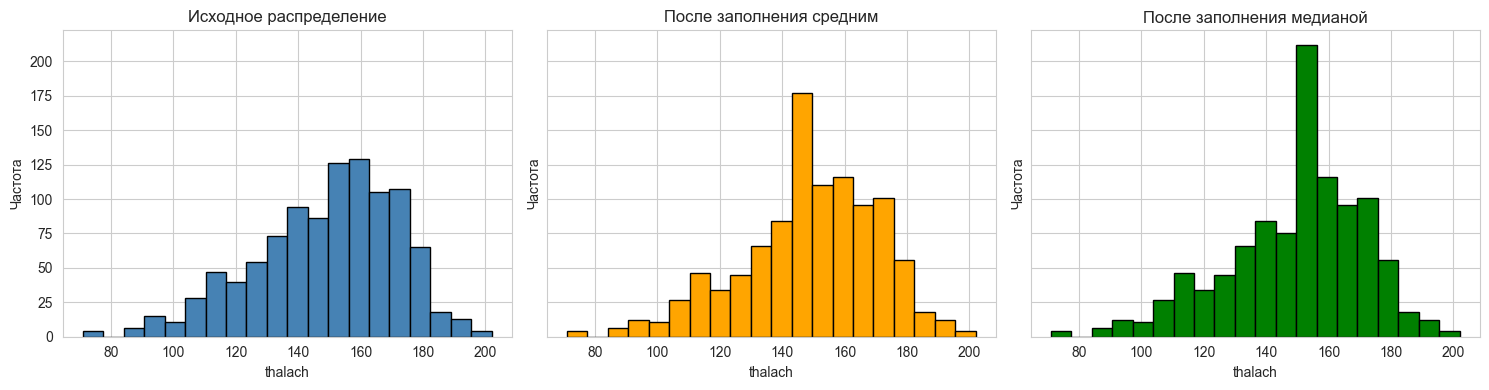

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

axes[0].hist(df[col_num].dropna(), bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Исходное распределение')
axes[0].set_xlabel(col_num)

axes[1].hist(df_mean[col_num], bins=20, color='orange', edgecolor='black')
axes[1].set_title('После заполнения средним')
axes[1].set_xlabel(col_num)

axes[2].hist(df_median[col_num], bins=20, color='green', edgecolor='black')
axes[2].set_title('После заполнения медианой')
axes[2].set_xlabel(col_num)

for ax in axes:
    ax.set_ylabel('Частота')

plt.tight_layout()
plt.show()

# Выводы:
# Для признака `thalach` распределение близко к симметричному (среднее ≈ 149.6, медиана = 152.0). 
# Заполнение и средним, и медианой даёт похожий результат.
# В качестве рабочего варианта выбираем **заполнение медианой** — оно устойчиво к выбросам и сохраняет больше информации, чем удаление 10% строк.

# 4. Обработка пропусков - Категориальный признак

In [30]:
col_cat = 'cp'

# мода
imp_mode = SimpleImputer(strategy='most_frequent')
df_mode = df_miss.copy()
df_mode[col_cat] = imp_mode.fit_transform(df_mode[[col_cat]]).ravel()

# константа
imp_const = SimpleImputer(strategy='constant', fill_value=99)
df_const = df_miss.copy()
df_const[col_cat] = imp_const.fit_transform(df_const[[col_cat]]).ravel()

print("Пропусков после заполнения модой:", df_mode[col_cat].isna().sum())
print("Пропусков после заполнения константой:", df_const[col_cat].isna().sum())

compare_cat = pd.DataFrame({
    'Исходные': df[col_cat].value_counts().sort_index(),
    'С пропусками': df_miss[col_cat].value_counts(dropna=False).sort_index(),
    'Заполнение модой': df_mode[col_cat].value_counts().sort_index(),
    'Заполнение константой (99)': df_const[col_cat].value_counts().sort_index(),
}).fillna(0).astype(int)

compare_cat

Пропусков после заполнения модой: 0
Пропусков после заполнения константой: 0


,Исходные,С пропусками,Заполнение модой,Заполнение константой (99)
cp,,,,
0.0,497,448,550,448
1.0,167,146,146,146
2.0,284,259,259,259
3.0,77,70,70,70
99.0,0,0,0,102
NaN,0,102,0,0


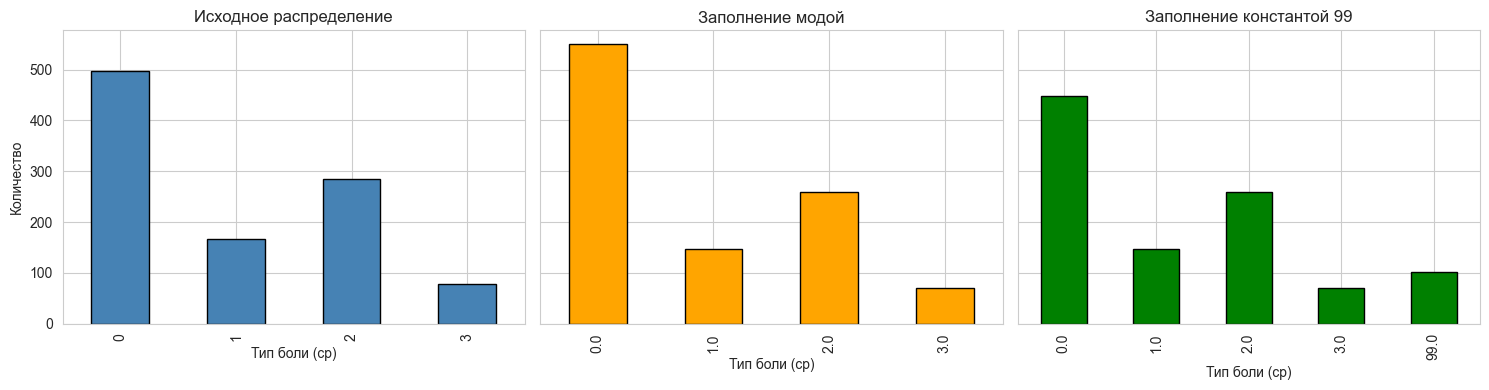

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

df[col_cat].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Исходное распределение')
axes[0].set_xlabel('Тип боли (cp)')

df_mode[col_cat].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='orange', edgecolor='black')
axes[1].set_title('Заполнение модой')
axes[1].set_xlabel('Тип боли (cp)')

df_const[col_cat].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='green', edgecolor='black')
axes[2].set_title('Заполнение константой 99')
axes[2].set_xlabel('Тип боли (cp)')

for ax in axes:
    ax.set_ylabel('Количество')

plt.tight_layout()
plt.show()

# Выводы:
# Мода = 0 (типичная стенокардия) — самое частое значение
# Заполнение модой сохраняет все 1025 наблюдений и не вводит новую категорию
# В качестве рабочего варианта выбираем **заполнение модой** **`SimpleImputer(strategy='most_frequent')`**

# **Задача №2**

## **Способы обработки пропусков:**
- Для количественного признака (thalach) использовали заполнение медианой. Медиана устойчива к выбросам, которые могут присутствовать в данных о ЧСС.
- Для категориального признака (cp) использовали заполнение модой (самым частым значением). Это сохраняет исходное распределение категорий.

## **Признаки для дальнейшего построения моделей:**
Будем использовать все признаки датасета:
- age, sex, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, cp
- целевая переменная: target

## Все признаки содержат информацию о состоянии пациента и могут быть полезны для предсказания сердечных заболеваний.

In [33]:
features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
            'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

X = df_median[features]
y = df_median['target']

np.random.seed(42)
shuffled_idx = np.random.permutation(len(X))
X_shuffled = X.iloc[shuffled_idx]
y_shuffled = y.iloc[shuffled_idx]

print(f"Признаки ({len(features)} шт.): {', '.join(features)}")
print(f"Целевая переменная: target")
print(f"\nРазмер X: {X.shape}")
print(f"Размер y: {y.shape}")
print(f"\nПервые 10 строк X:")
print(X_shuffled.head(10))
print(f"\nПервые 10 значений y:")
print(y_shuffled.head(10).values)

Признаки (13 шт.): age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal
Целевая переменная: target

Размер X: (1025, 13)
Размер y: (1025,)

Первые 10 строк X:
     age  sex   cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
527   62    0  0.0       124   209    0        1    163.0      0      0.0   
359   53    0  2.0       128   216    0        0    115.0      0      0.0   
447   55    1  0.0       160   289    0        0    152.0      1      0.8   
31    50    0  1.0       120   244    0        1    162.0      0      1.1   
621   48    1  0.0       130   256    1        0    150.0      1      0.0   
590   74    0  1.0       120   269    0        0    152.0      1      0.2   
905   64    1  0.0       120   246    0        0     96.0      1      2.2   
737   67    1  0.0       120   229    0        0    129.0      1      2.6   
76    48    1  2.0       124   255    1        1    175.0      0      0.0   
948   70    1  0.0       145   174    0

# 5. Доп. требование (ИУ5-62Б) - Гистограмма

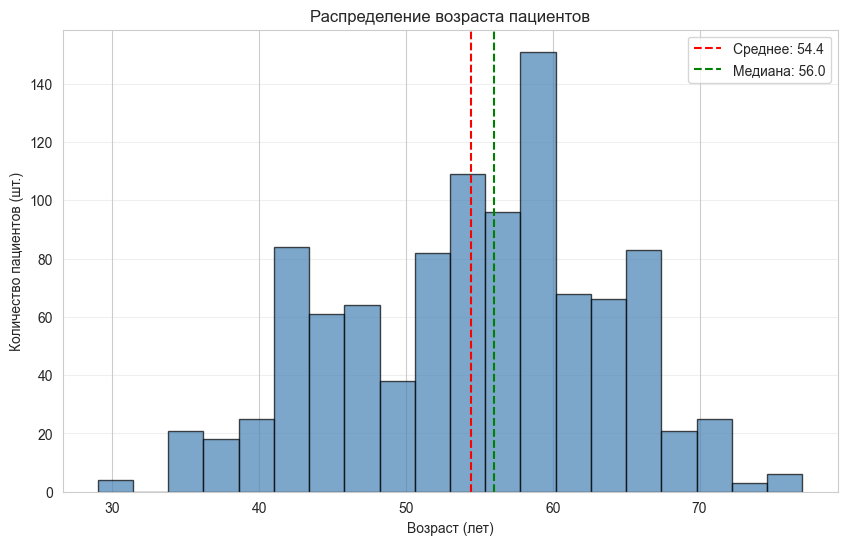

Минимум: 29, Максимум: 77


In [34]:
plt.figure(figsize=(10, 6))
plt.hist(df['age'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(df['age'].mean(), color='red', linestyle='--', label=f'Среднее: {df["age"].mean():.1f}')
plt.axvline(df['age'].median(), color='green', linestyle='--', label=f'Медиана: {df["age"].median():.1f}')
plt.xlabel('Возраст (лет)')
plt.ylabel('Количество пациентов (шт.)')
plt.title('Распределение возраста пациентов')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Минимум: {df['age'].min()}, Максимум: {df['age'].max()}")

# Распределение возраста имеет положительную асимметрию. Большинство пациентов находятся в возрасте 50–60 лет. 
# Пик приходится на 55–60 лет. Молодых пациентов (до 40 лет) мало, что соответствует эпидемиологии сердечно-сосудистых заболеваний.


# **Общий вывод по работе с датасетом для РК №1:**

# 1. **Для количественного признака** `thalach` использовали `SimpleImputer(strategy='median')` — медиана устойчива к выбросам и сохраняет полный объём выборки.
# 2. **Для категориального признака** `cp` использовали `SimpleImputer(strategy='most_frequent')` — заполнение модой сохраняет исходное распределение категорий.
# 3. **Для построения моделей машинного обучения** будем использовать все 13 признаков. Наиболее информативными ожидаются `cp`, `thalach`, `exang`, `oldpeak` — у них наивысшая корреляция с целевой переменной.
# 4. После обработки пропусков данные стали полными (0 пропусков) и готовы к обучению.


